# TrOCR-5-2


In [1]:
%pip install -q transformers albumentations editdistance
import os, cv2, torch, random, editdistance, re
import numpy as np, pandas as pd
import albumentations as A
from pathlib import Path
from sklearn.model_selection import train_test_split
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from google.colab import drive, userdata
import kagglehub
import random
from datetime import datetime

## ================= 1. НАСТРОЙКИ И ИНИЦИАЛИЗАЦИЯ ================

In [2]:
# Монтирование диска
drive.mount('/content/drive')

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

DRIVE_DIR = Path(f"/content/drive/MyDrive/ocr_checkpoints_{timestamp}")
DRIVE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_CSV = "submission.csv"

# Аутентификация в кегель через колабовскую секретницу
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
os.environ['KAGGLEHUB_CACHE'] = '/content/kaggle_cache'

# Скачка датасета
dataset_path = "denccchicck/dl-lab-4-ocr-custom-dataset"
DATA_DIR = Path(kagglehub.dataset_download(dataset_path))

# Модель
BATCH_SIZE = 20
NUM_EPOCHS = 7
LR = 1e-5
MAX_LEN = 6  # [BOS], x, x, x, x, [EOS]
DEVICE = "cuda"
NUM_WORKERS = os.cpu_count() or 2

# Сиды
seed = 42
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.backends.cudnn.benchmark = True

Mounted at /content/drive


100%|██████████| 52.8M/52.8M [00:00<00:00, 92.2MB/s]

Extracting files...


## ================= 2. ПРЕПРОЦЕССИНГ И АУГМЕНТАЦИИ =================

In [3]:
class PadToSquare(A.ImageOnlyTransform):
    def __init__(self, always_apply=True, p=1.0):
        super().__init__(always_apply=always_apply, p=p)

    def apply(self, img, **params):
        h, w = img.shape[:2]
        size = max(h, w)
        pad_h, pad_w = size - h, size - w
        return cv2.copyMakeBorder(img, pad_h//2, pad_h - pad_h//2, pad_w//2, pad_w - pad_w//2, cv2.BORDER_CONSTANT, value=[255, 255, 255])

class AlphaBlending(A.ImageOnlyTransform):
    def __init__(self, alpha_range=(0.2, 0.5), always_apply=False, p=1.0):
        super().__init__(always_apply=always_apply, p=p)
        self.alpha_range = alpha_range

    def apply(self, img, **params):
        alpha = random.uniform(*self.alpha_range)
        bg = np.full(img.shape, 240, dtype=np.uint8)
        return cv2.addWeighted(img, 1 - alpha, bg, alpha, 0)

class CropTop(A.ImageOnlyTransform):
    def __init__(self, crop_percent_range=(0.10, 0.15), always_apply=False, p=1.0):
        super().__init__(always_apply=always_apply, p=p)
        self.crop_percent_range = crop_percent_range

    def apply(self, img, **params):
        h, w = img.shape[:2]
        crop_percent = random.uniform(*self.crop_percent_range)
        crop_h = int(h * crop_percent)
        top = random.randint(0, crop_h)
        return img[top:, :]

class CropBottom(A.ImageOnlyTransform):
    def __init__(self, crop_percent_range=(0.10, 0.15), always_apply=False, p=1.0):
        super().__init__(always_apply=always_apply, p=p)
        self.crop_percent_range = crop_percent_range

    def apply(self, img, **params):
        h, w = img.shape[:2]
        crop_percent = random.uniform(*self.crop_percent_range)
        crop_h = int(h * crop_percent)
        bottom = random.randint(0, crop_h)
        return img[:h - bottom, :]

class CropLeft(A.ImageOnlyTransform):
    def __init__(self, crop_percent_range=(0.10, 0.15), always_apply=False, p=1.0):
        super().__init__(always_apply=always_apply, p=p)
        self.crop_percent_range = crop_percent_range

    def apply(self, img, **params):
        h, w = img.shape[:2]
        crop_percent = random.uniform(*self.crop_percent_range)
        crop_w = int(w * crop_percent)
        left = random.randint(0, crop_w)
        return img[:, left:]

class CropRight(A.ImageOnlyTransform):
    def __init__(self, crop_percent_range=(0.10, 0.15), always_apply=False, p=1.0):
        super().__init__(always_apply=always_apply, p=p)
        self.crop_percent_range = crop_percent_range

    def apply(self, img, **params):
        h, w = img.shape[:2]
        crop_percent = random.uniform(*self.crop_percent_range)
        crop_w = int(w * crop_percent)
        right = random.randint(0, crop_w)
        return img[:, :w - right]


train_tfm = A.Compose([

    # 1. Яркость и контраст
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=(-0.35, -0.25), contrast_limit=0, p=1.0),
        A.RandomBrightnessContrast(brightness_limit=(0.3, 0.5), contrast_limit=0, p=1.0),
        A.RandomBrightnessContrast(brightness_limit=0, contrast_limit=(0.45, 0.55), p=1.0),
    ], p=0.6),

    # 2. Цветовые искажения
    A.OneOf([
        A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=1.0),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=10, p=1.0),
    ], p=0.7),

    # 3. Alpha Blending (выцветание)
    AlphaBlending(alpha_range=(0.2, 0.5), p=0.3),

    # 4. Рандомный кроп ОДНОЙ стороны (10-15% от размера)
    A.OneOf([
        CropTop(crop_percent_range=(0.10, 0.15), p=1.0),
        CropBottom(crop_percent_range=(0.10, 0.15), p=1.0),
        CropLeft(crop_percent_range=(0.10, 0.15), p=1.0),
        CropRight(crop_percent_range=(0.10, 0.15), p=1.0),
    ], p=0.1),

    # 5. Motion Blur
    A.MotionBlur(blur_limit=7, p=0.2),

    # 6. Паддинг до квадрата (ВСЕГДА ПОСЛЕДНИЙ ШАГ, чтобы поля оставались чисто белыми)
    PadToSquare(always_apply=True)
])

# На валидации применяем только паддинг
val_tfm = A.Compose([
    PadToSquare(always_apply=True)
])

/tmp/ipykernel_6049/1261382725.py:13: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)
/tmp/ipykernel_6049/1261382725.py:23: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)
/tmp/ipykernel_6049/1261382725.py:35: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)
/tmp/ipykernel_6049/1261382725.py:47: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)
/tmp/ipykernel_6049/1261382725.py:59: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)
/tmp/ipykernel_6049/1261382725.py:3: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(a

## ================= 3. ДАТАСЕТ И РАЗБИЕНИЕ =================

In [4]:
import matplotlib.pyplot as plt

NESTED_DATA_DIR = DATA_DIR / 'dl-lab-4-ocr-custom-dataset-v3'
train_df = pd.read_csv(NESTED_DATA_DIR / 'train.csv')
val_df = pd.read_csv(NESTED_DATA_DIR / 'val.csv')

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")

class PriceDataset(Dataset):
    def __init__(self, df, img_dir, tfms=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.tfms = tfms
        self.is_test = is_test

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = str(self.img_dir / row['Filename'])

        # Используем imdecode для поддержки кириллицы в путях
        img = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Применяем аугментации (теперь pad_to_square внутри них)
        if self.tfms:
            img = self.tfms(image=img)['image']

        pixel_values = processor(images=img, return_tensors="pt").pixel_values.squeeze()

        if self.is_test:
            return pixel_values, row['Filename']

        text = str(row['Price'])
        labels = processor.tokenizer(text, padding="max_length", max_length=MAX_LEN, truncation=True).input_ids
        labels = [l if l != processor.tokenizer.pad_token_id else -100 for l in labels]

        return pixel_values, torch.tensor(labels)

train_loader = DataLoader(
    PriceDataset(train_df, NESTED_DATA_DIR / 'train/train', tfms=train_tfm),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=True, persistent_workers=True
)

val_loader = DataLoader(
    PriceDataset(val_df, NESTED_DATA_DIR / 'val/val', tfms=val_tfm),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=True, persistent_workers=True
)

print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Train samples: 33500, Val samples: 15050


/usr/local/lib/python3.12/dist-packages/albumentations/augmentations/blur/functional.py:232: UserWarning: blur_limit: Non-zero kernel sizes must be odd. Range (3, 12) automatically adjusted to (3, 13).
  result = _ensure_odd_values(result, info.field_name)


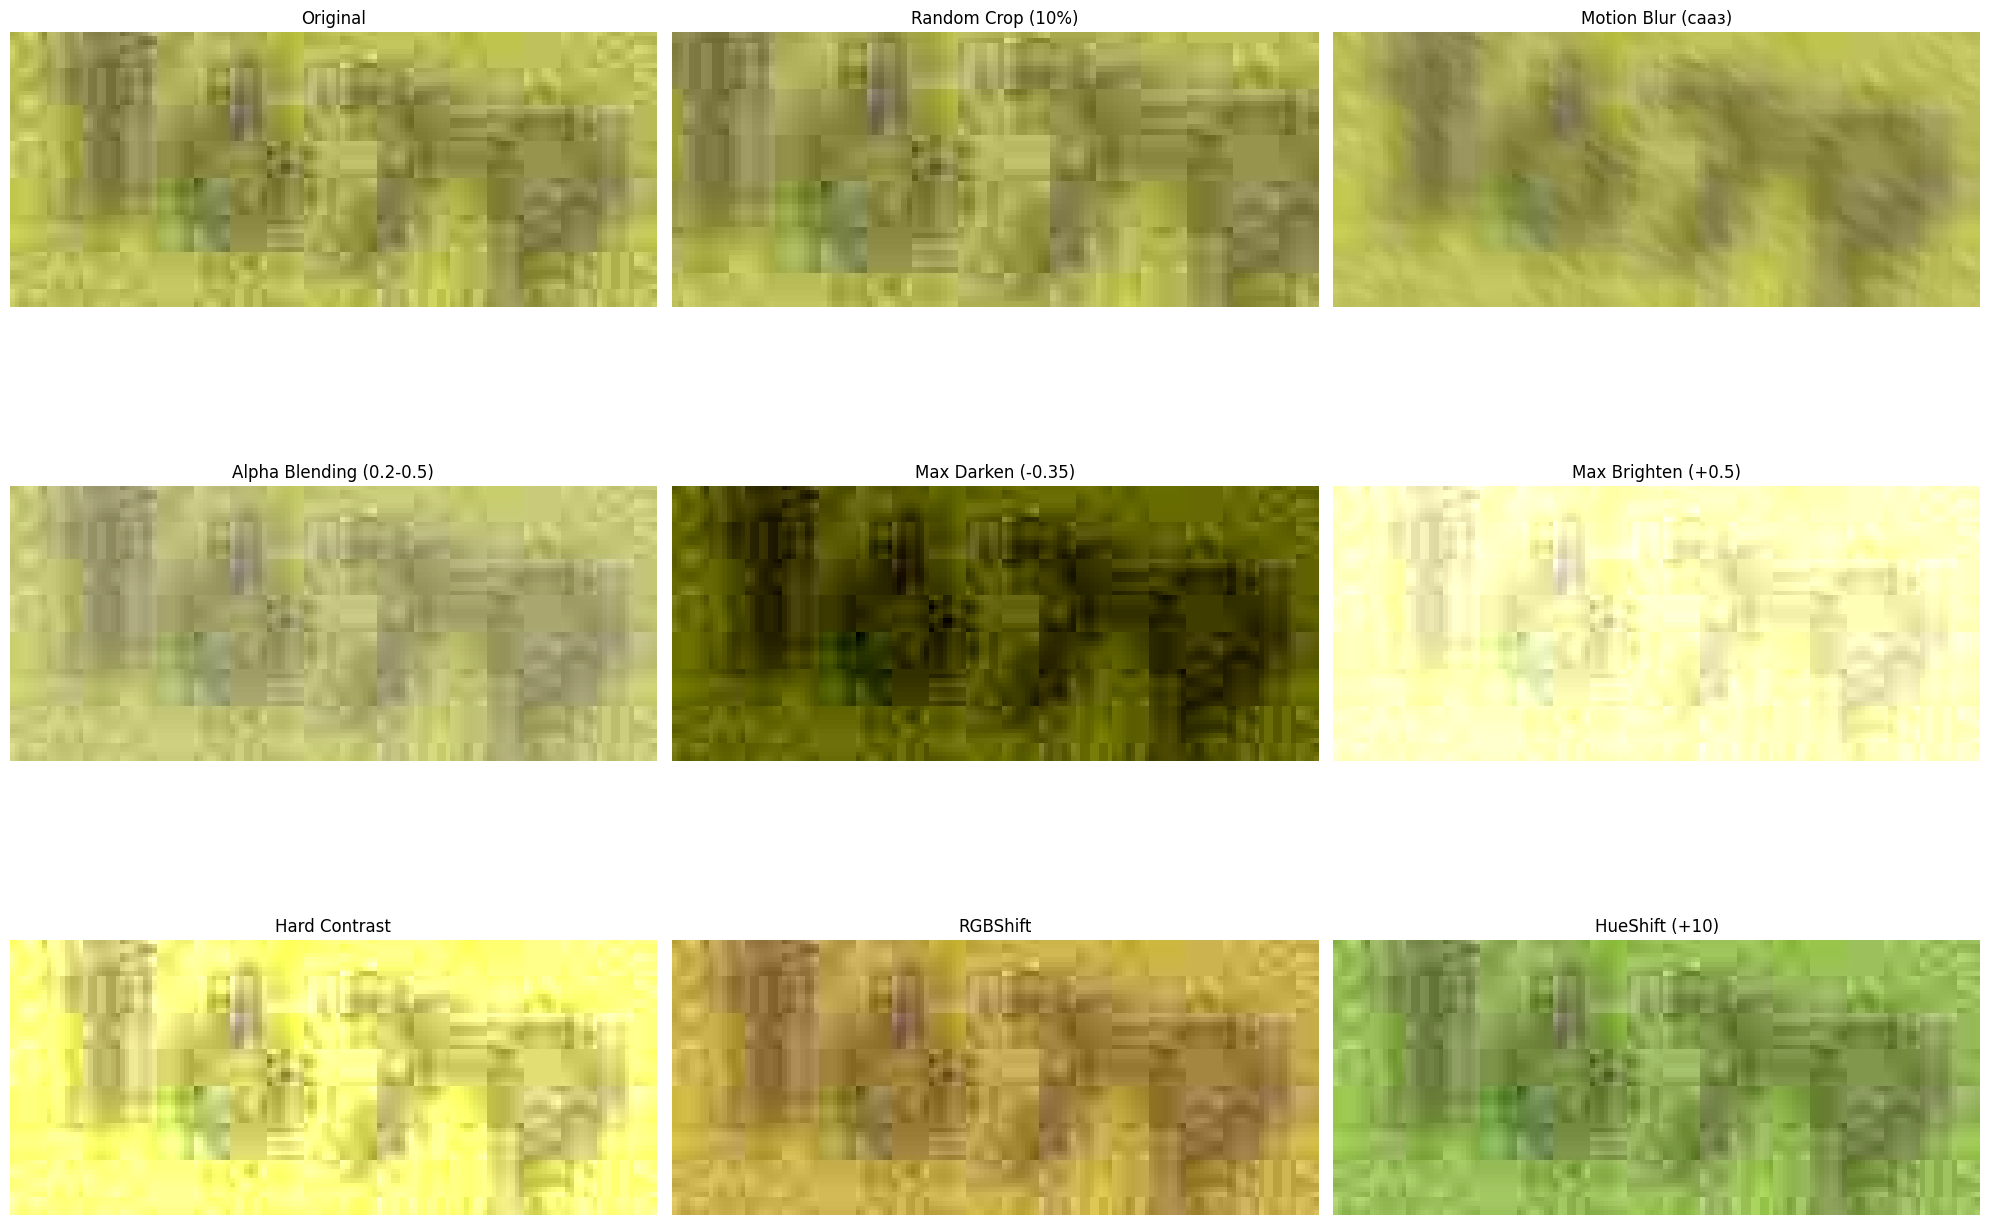

In [5]:
import cv2
import numpy as np
import albumentations as A
import matplotlib.pyplot as plt
import random
from pathlib import Path

def alpha_blending(image, **kwargs):
    """Смешивание изображения с фоном"""
    alpha = random.uniform(0.2, 0.5)
    bg = np.full(image.shape, 240, dtype=np.uint8)
    blended = cv2.addWeighted(image, 1 - alpha, bg, alpha, 0)
    return blended

def test_standalone_augs(image_path):
    img = cv2.imdecode(np.fromfile(str(image_path), dtype=np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        print("Image not found!")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]
    crop_h = int(h * 0.1)
    crop_w = int(w * 0.1)

    test_transforms = [
        ("Original", None),
        ("Random Crop (10%)", A.Crop(x_min=crop_w, y_min=crop_h, x_max=w - crop_w, y_max=h - crop_h, p=1.0)),
        ("Motion Blur", A.MotionBlur(blur_limit=12, p=1.0)),
        ("Alpha Blending (0.2-0.5)", A.Lambda(image=alpha_blending, p=1.0)),
        ("Max Darken (-0.35)", A.RandomBrightnessContrast(brightness_limit=(-0.25, -0.35), contrast_limit=0, p=1.0)),
        ("Max Brighten (+0.5)", A.RandomBrightnessContrast(brightness_limit=(0.3, 0.5), contrast_limit=0, p=1.0)),
        ("Hard Contrast", A.RandomBrightnessContrast(brightness_limit=0, contrast_limit=(0.5, 0.5), p=1.0)),
        ("RGBShift", A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=1.0)),
        ("HueShift (+10)", A.HueSaturationValue(hue_shift_limit=(10, 10), sat_shift_limit=0, val_shift_limit=0, p=1.0)),
    ]

    n = len(test_transforms)
    cols = 3
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(20, 5 * rows))
    for i, (name, aug) in enumerate(test_transforms):
        plt.subplot(rows, cols, i + 1)
        if aug:
            augmented = aug(image=img.copy())['image']
            plt.imshow(augmented)
        else:
            plt.imshow(img)
        plt.title(name)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

random_idx = random.randint(0, len(train_df) - 1)
sample_img_path = NESTED_DATA_DIR / 'train/train' / train_df.iloc[random_idx]['Filename']
test_standalone_augs(sample_img_path)

## ================= 4. МОДЕЛЬ =================

In [6]:
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.generation_config.max_length = 6
model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(len(train_loader)*0.1), num_training_steps=len(train_loader)*NUM_EPOCHS)
scaler = torch.amp.GradScaler('cuda')

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## ================= 5. ОБУЧЕНИЕ =================

In [7]:
best_cer = float('inf')

for ep in range(1, NUM_EPOCHS + 1):
    model.train()
    tr_loss = 0

    pbar = tqdm(train_loader, desc=f"Ep {ep}/{NUM_EPOCHS} Train", leave=False)
    for px, lbl in pbar:
        px, lbl = px.to(DEVICE, non_blocking=True), lbl.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            loss = model(pixel_values=px, labels=lbl).loss
            tr_loss += loss.item()

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        old_scale = scaler.get_scale()
        scaler.update()

        if old_scale <= scaler.get_scale():
            scheduler.step()

    model.eval()
    val_loss, total_chars, total_errors, exact_matches, wrong_count = 0, 0, 0, 0, 0

    with torch.no_grad():
        for px, lbl in tqdm(val_loader, desc="Val", leave=False):
            px, lbl = px.to(DEVICE, non_blocking=True), lbl.to(DEVICE, non_blocking=True)

            with torch.amp.autocast('cuda'):
                loss = model(pixel_values=px, labels=lbl).loss
                val_loss += loss.item()
                gen_ids = model.generate(px, max_length=MAX_LEN)

            preds = processor.batch_decode(gen_ids, skip_special_tokens=True)
            lbl[lbl == -100] = processor.tokenizer.pad_token_id
            truths = processor.batch_decode(lbl, skip_special_tokens=True)

            for p, t in zip(preds, truths):
                p, t = p.strip(), t.strip()
                if p == t:
                  exact_matches += 1
                else:
                  wrong_count += 1
                total_errors += editdistance.eval(p, t)
                total_chars += max(len(t), 1)

    cer = total_errors / total_chars
    acc = exact_matches / len(val_df)
    print(f"Ep {ep} | TrLoss: {tr_loss/len(train_loader):.4f} | ValLoss: {val_loss/len(val_loader):.4f} | CER: {cer:.4f} | Wrong: {wrong_count} | Exact: {acc:.4f}")

    if cer < best_cer:
        best_cer = cer
        model.save_pretrained(DRIVE_DIR / "best_model")
        processor.save_pretrained(DRIVE_DIR / "best_model")
        print(f"- Лучшая модель (CER: {cer:.4f}) сохранена на Drive")

Ep 1/7 Train:   0%|          | 0/1675 [00:00<?, ?it/s]

Val:   0%|          | 0/753 [00:00<?, ?it/s]

Ep 1 | TrLoss: 0.3231 | ValLoss: 0.0415 | CER: 0.0088 | Exact: 0.9798


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

- Лучшая модель (CER: 0.0088) сохранена на Drive


...

Val:   0%|          | 0/753 [00:00<?, ?it/s]

Ep 6 | TrLoss: 0.0211 | ValLoss: 0.0511 | CER: 0.0082 | Exact: 0.9807


Ep 7/7 Train:   0%|          | 0/1675 [00:00<?, ?it/s]

Val:   0%|          | 0/753 [00:00<?, ?it/s]

Ep 7 | TrLoss: 0.0187 | ValLoss: 0.0370 | CER: 0.0064 | Exact: 0.9852


## ================= 6. ИНФЕРЕНС =================

In [9]:
test_df = pd.read_csv(NESTED_DATA_DIR / 'sample_submission.csv')
test_loader = DataLoader(
    PriceDataset(test_df, NESTED_DATA_DIR / 'test/test', tfms=val_tfm, is_test=True),
    batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2
)

model.eval()
results = []

with torch.no_grad():
    for px, fnames in tqdm(test_loader, desc="Predicting"):
        px = px.to(DEVICE)
        with torch.amp.autocast('cuda'):
            gen_ids = model.generate(px, max_length=MAX_LEN)

        preds = processor.batch_decode(gen_ids, skip_special_tokens=True)

        for fname, pred in zip(fnames, preds):
            clean_price = re.sub(r'\D', '', pred)
            results.append({'Filename': fname, 'Price': int(clean_price) if clean_price else 0})

final_df = pd.DataFrame(results)
final_df.to_csv(OUTPUT_CSV, index=False)
drive_csv_path = DRIVE_DIR / "submission.csv"
final_df.to_csv(drive_csv_path, index=False)

print(f"Готово! Файл сохранен в двух местах:")
print(f"1) Локально: {OUTPUT_CSV}")
print(f"2) На Drive:  {drive_csv_path}")

Predicting:   0%|          | 0/95 [00:00<?, ?it/s]

Готово! Файл сохранен в двух местах:
1) Локально: submission.csv
2) На Drive:  /content/drive/MyDrive/ocr_checkpoints/submission.csv


## ================= 7. Анализ ошибок =================

In [13]:
import shutil

MISTAKES_DIR = DRIVE_DIR / "mistake_images"
MISTAKES_DIR.mkdir(parents=True, exist_ok=True)

model.eval()

class ValDatasetWithFnames(Dataset):
    def __init__(self, df, img_dir, tfms=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.tfms = tfms

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = str(self.img_dir / row['Filename'])

        img = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.tfms:
            img = self.tfms(image=img)['image']

        pixel_values = processor(images=img, return_tensors="pt").pixel_values.squeeze()

        text = str(row['Price'])
        labels = processor.tokenizer(text, padding="max_length", max_length=MAX_LEN, truncation=True).input_ids
        labels = [l if l != processor.tokenizer.pad_token_id else -100 for l in labels]

        return pixel_values, torch.tensor(labels), row['Filename']

error_loader = DataLoader(
    ValDatasetWithFnames(val_df, NESTED_DATA_DIR / 'val' / 'val', tfms=val_tfm),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

error_cases = []

with torch.no_grad():
    for px, lbl, fnames in tqdm(error_loader, desc="Analyzing & Saving Errors"):
        px = px.to(DEVICE)
        with torch.amp.autocast('cuda'):
            gen_ids = model.generate(px, max_length=MAX_LEN)

        preds = processor.batch_decode(gen_ids, skip_special_tokens=True)

        lbl[lbl == -100] = processor.tokenizer.pad_token_id
        truths = processor.batch_decode(lbl, skip_special_tokens=True)

        for p, t, fn in zip(preds, truths, fnames):
            p, t = p.strip(), t.strip()
            if p != t:
                error_cases.append({'Filename': fn, 'true': t, 'pred': p})
                src_path = NESTED_DATA_DIR / 'val' / 'val' / fn
                # Фаравируев вавае ибу с резувстатави
                dst_name = f"pred_{p}_true_{t}_{fn}"
                dst_path = MISTAKES_DIR / dst_name
                try:
                    shutil.copy(str(src_path), str(dst_path))
                except Exception as e:
                    print(f"{fn}: {e}")

error_df = pd.DataFrame(error_cases)
print(f"Найдено и сохранено ошибок: {len(error_df)} из {len(val_df)}")
print(f"Путь к папке: {MISTAKES_DIR}")
if not error_df.empty:
    display(error_df.head(20))
else:
    print("Нет ошибок на валидации")

Analyzing & Saving Errors:   0%|          | 0/753 [00:00<?, ?it/s]

Вайдева и сахравева ашибав: 222 из 15050
Бутс в бабве: /content/drive/MyDrive/ocr_checkpoints/mistake_images


,Filename,true,pred
0,0_10-B4-1D-C8-03-8C_17_2025-11-12-17-03-31.jpg,99,89
1,0_10-B4-1D-C8-02-C8_37_2025-11-17-10-59-28.jpg,39,139
2,30_D0-CF-13-23-CB-1C_2026-01-22-17-59-40.jpg,110,410
3,14_D0-CF-13-19-1A-00_2026-01-22-21-59-03.jpg,729,129
4,0_10-B4-1D-C8-00-D0_48_2025-11-11-10-07-19.jpg,69,36
5,0_10-B4-1D-E0-1D-64_32_2025-11-13-19-59-09.jpg,69,39
6,35_10-B4-1D-C8-0A-B8_2026-01-22-14-04-39.jpg,54,52
7,31_10-B4-1D-E0-20-80_2026-01-22-22-01-10.jpg,799,299
8,22_D0-CF-13-23-50-0C_2026-01-22-22-00-25.jpg,89,99
9,0_D0-CF-13-21-68-B0_21_2025-11-12-10-58-34.jpg,34,3


## ================= 8. Дообучение на ошибках =================

In [15]:
# --- ПОДГОТОВКА ДАННЫХ ДЛЯ FINE-TUNING ---

# 1. Создаем dataframe с ошибками
hard_df = error_df[['Filename', 'true']].rename(columns={'true': 'Price'})
hard_df['Price'] = hard_df['Price'].astype(str)
# Добавляем метку, что это файлы из папки val
hard_df['img_folder'] = 'val/val'

# 2. Оверсэмплинг
hard_df_expanded = pd.concat([hard_df] * 20, ignore_index=True)

# 3. Берем базу из трейна и добавляем метку папки
base_train_df = pd.read_csv(NESTED_DATA_DIR / 'train.csv')
base_train_df['Price'] = base_train_df['Price'].astype(str)
base_train_df['img_folder'] = 'train/train'

mix_df = pd.concat([hard_df_expanded, base_train_df.sample(n=3000, random_state=42)], ignore_index=True)

# 5. Обновленный класс Dataset для поддержки разных папок
class FineTuneDataset(PriceDataset):
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Используем папку, указанную в dataframe
        img_path = str(NESTED_DATA_DIR / row['img_folder'] / row['Filename'])

        img = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.tfms:
            img = self.tfms(image=img)['image']

        pixel_values = processor(images=img, return_tensors="pt").pixel_values.squeeze()
        text = str(row['Price'])
        labels = processor.tokenizer(text, padding="max_length", max_length=MAX_LEN, truncation=True).input_ids
        labels = [l if l != processor.tokenizer.pad_token_id else -100 for l in labels]

        return pixel_values, torch.tensor(labels)

# 4. Создаем новый DataLoader
fine_tune_dataset = FineTuneDataset(mix_df, NESTED_DATA_DIR, tfms=train_tfm)
fine_tune_loader = DataLoader(
    fine_tune_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True
)

# --- ДООБУЧЕНИЕ ---

model_ft = VisionEncoderDecoderModel.from_pretrained(DRIVE_DIR / "best_model")
model_ft.to(DEVICE)

optimizer = torch.optim.AdamW(model_ft.parameters(), lr=1e-6, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=len(fine_tune_loader)*3)
scaler = torch.amp.GradScaler('cuda')

model_ft.train()
print("Starting Fine-tuning on hard examples...")

for ep in range(1, 4):
    tr_loss = 0
    pbar = tqdm(fine_tune_loader, desc=f"Fine-tune Ep {ep}")
    for px, lbl in pbar:
        px, lbl = px.to(DEVICE), lbl.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            loss = model_ft(pixel_values=px, labels=lbl).loss
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        tr_loss += loss.item()
        pbar.set_postfix(loss=f"{tr_loss/len(pbar):.4f}")

# --- ИНФЕРЕНС ---

model_ft.eval()
print("Predicting with Fine-tuned model...")
test_loader = DataLoader(
    PriceDataset(pd.read_csv(NESTED_DATA_DIR / 'sample_submission.csv'), NESTED_DATA_DIR / 'test/test', tfms=val_tfm, is_test=True),
    batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0
)

results_ft = []
with torch.no_grad():
    for px, fnames in tqdm(test_loader, desc="Predicting"):
        gen_ids = model_ft.generate(px.to(DEVICE), max_length=MAX_LEN)
        preds = processor.batch_decode(gen_ids, skip_special_tokens=True)
        for fname, pred in zip(fnames, preds):
            clean_price = re.sub(r'\D', '', pred)
            results_ft.append({'Filename': fname, 'Price': int(clean_price) if clean_price else 0})

final_df_ft = pd.DataFrame(results_ft)
final_df_ft.to_csv("submission_ft.csv", index=False)
print("Готово! Сабмишн сохранен как submission_ft.csv")

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Starting Fine-tuning on hard examples...


Fine-tune Ep 1:   0%|          | 0/372 [00:00<?, ?it/s]

Fine-tune Ep 2:   0%|          | 0/372 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cc5773a9620>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cc5773a9620>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cc5773a9620>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cc5773a9620>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Predicting with Fine-tuned model...


Predicting:   0%|          | 0/95 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cc5773a9620>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cc5773a9620>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Готово! Сабмишн сохранен как submission_ft.csv


## ================= 9. Анализ разницы предсказаний дообученной модели и исходной =================

In [20]:
df_base = pd.read_csv("submission.csv")
df_ft = pd.read_csv("submission_ft.csv")

df_comp = pd.merge(df_base, df_ft, on='Filename', suffixes=('_base', '_ft'))
diff_df = df_comp[df_comp['Price_base'] != df_comp['Price_ft']].copy()

print(f"Всего предсказаний: {len(df_comp)}")
print(f"Различий найдено: {len(diff_df)}")

# Проверяем, в ту ли папку мы смотрим
print(f"Целевая папка Drive: {DRIVE_DIR}")
DISC_DIR = DRIVE_DIR / "discrepancies"
DISC_DIR.mkdir(parents=True, exist_ok=True)

diff_df.to_csv(DRIVE_DIR / "comparison_summary.csv", index=False)

print("Копирование изображений с расхождениями...")
# Используем NESTED_DATA_DIR, так как DATA_DIR может содержать лишние подпапки версий
test_img_dir = NESTED_DATA_DIR / 'test' / 'test'

copy_count = 0
for _, row in tqdm(diff_df.iterrows(), total=len(diff_df)):
    fname = row['Filename']
    src = test_img_dir / fname
    if src.exists():
        new_name = f"base_{row['Price_base']}_ft_{row['Price_ft']}_{fname}"
        dst = DISC_DIR / new_name
        shutil.copy(str(src), str(dst))
        copy_count += 1
    else:
        print(f"Внимание: Файл не найден: {src}")

print(f"Готово! Скопировано файлов: {copy_count}")

Всего предсказаний: 3762
Различий найдено: 93
Целевая папка Drive: /content/drive/MyDrive/ocr_checkpoints
Копирование изображений с расхождениями...


  0%|          | 0/93 [00:00<?, ?it/s]

Готово! Скопировано файлов: 93
Проверьте путь еще раз: /content/drive/MyDrive/ocr_checkpoints/discrepancies
